In [1]:

# PART A - Task 1: Loading and Preprocessing the Dataset (Apache Spark)
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, when

# Create Spark Session
spark = SparkSession.builder \
    .appName("UK Crime Data Loading and Preprocessing") \
    .getOrCreate()


# Load CSV Files for Derbyshire, Leicestershire, Nottinghamshire
data_path = "/kaggle/input/crimedataset/CrimeSet1"  

# Load all CSV files
df = spark.read.option("header", True) \
               .option("inferSchema", True) \
               .option("recursiveFileLookup", True) \
               .csv(data_path)


# Show sample of loaded data
df.show(5)
df.printSchema()


# Standardise County Names
# Map 'Reported by' values to simplified 'County' names
df = df.withColumn(
    "County",
    when(col("Reported by").contains("Derbyshire"), lit("Derbyshire"))
    .when(col("Reported by").contains("Leicestershire"), lit("Leicestershire"))
    .when(col("Reported by").contains("Nottinghamshire"), lit("Nottinghamshire"))
    .otherwise(lit("Unknown"))
)


# Data Cleaning and Verification
# Remove duplicates
df = df.dropDuplicates(["Crime ID"])

# Check for missing values per column
print("Missing values per column:")
for c in df.columns:
    missing = df.filter(col(c).isNull()).count()
    print(f"{c}: {missing}")

# Show cleaned data
df.select("Crime ID", "Month", "Reported by", "County", "Crime type").show(5)


# Handling Column Names and Inconsistencies
# Rename columns for consistency
df = df.withColumnRenamed("Crime type", "Crime_Type").withColumnRenamed("Last outcome category", "Outcome_Category")

# Verify all expected columns are present
expected_cols = ["Crime ID", "Month", "Reported by", "Longitude", "Latitude", "Location", "LSOA code", "LSOA name", "Crime_Type", "Outcome_Category", "County"]
print("\nColumns in DataFrame:")
print(df.columns)

# Ensure all expected columns exist
missing_cols = [c for c in expected_cols if c not in df.columns]
if missing_cols:
    print(f"Warning: Missing columns - {missing_cols}")


# Save cleaned DataFrame as temporary SQL view for next tasks
df.createOrReplaceTempView("crime_data")




Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/14 11:13:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|            Crime ID|              Month|         Reported by|        Falls within|Longitude| Latitude|            Location|LSOA code|        LSOA name|          Crime type|Last outcome category|Context|
+--------------------+-------------------+--------------------+--------------------+---------+---------+--------------------+---------+-----------------+--------------------+---------------------+-------+
|58047a3a95167140d...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.347639|53.061766|On or near Regent...|E01019444|Amber Valley 003B|Violence and sexu...| Court result unav...|   NULL|
|8ac857a6be54f5424...|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire P...|-1.329102|53.024519|On or near Minkle...|E01019451|Amber Valley 012D|               Drugs| Unabl

Crime ID: 1


Month: 0


Reported by: 0


...

LSOA name: 8681


Crime type: 0


Last outcome category: 1


Context: 578159
County: 0


+--------------------+-------------------+--------------------+---------------+--------------------+
|            Crime ID|              Month|         Reported by|         County|          Crime type|
+--------------------+-------------------+--------------------+---------------+--------------------+
|                NULL|2023-05-01 00:00:00|Nottinghamshire P...|Nottinghamshire|Anti-social behav...|
|0000bd10ccaa6ddbc...|2023-12-01 00:00:00|Nottinghamshire P...|Nottinghamshire|         Shoplifting|
|000182171e962da46...|2024-07-01 00:00:00|Nottinghamshire P...|Nottinghamshire|Violence and sexu...|
|0001dbf1a3e747ac9...|2024-02-01 00:00:00|Derbyshire Consta...|     Derbyshire|Criminal damage a...|
|000200489db22e0c6...|2023-06-01 00:00:00|Derbyshire Consta...|     Derbyshire|         Other theft|
+--------------------+-------------------+--------------------+---------------+--------------------+
only showing top 5 rows


Columns in DataFrame:
['Crime ID', 'Month', 'Reported by', 'Falls

In [2]:

# PART A - Task 2: Descriptive Data Analysis using Spark SQL
from pyspark.sql.functions import substring

# Extract Year and Month for easier grouping
# If Month is a timestamp, convert to string 'yyyy-MM'
df = df.withColumn("Year", substring(col("Month"), 1, 4)) \
       .withColumn("MonthNum", substring(col("Month"), 6, 2))

df.createOrReplaceTempView("crime_data")


# Total Crimes by County 

total_crimes_by_county = spark.sql("""
    SELECT County,
           COUNT(*) AS Total_Crimes
    FROM crime_data
    GROUP BY County
    ORDER BY Total_Crimes DESC
""")

print("=== Total Crimes by County (2023–2024) ===")
total_crimes_by_county.show()



# Monthly Crime Trends 
monthly_crime_trends = spark.sql("""
    SELECT County,
           Year,
           MonthNum,
           COUNT(*) AS Total_Crimes
    FROM crime_data
    GROUP BY County, Year, MonthNum
    ORDER BY County, Year, MonthNum
""")

print("=== Monthly Crime Trends by County ===")
monthly_crime_trends.show(10)


# Identify highest and lowest months for each county
highest_lowest = spark.sql("""
    SELECT County, 
           Year,
           MonthNum,
           Total_Crimes
    FROM (
        SELECT County,
               Year,
               MonthNum,
               COUNT(*) AS Total_Crimes,
               ROW_NUMBER() OVER(PARTITION BY County ORDER BY COUNT(*) DESC) AS rank_high,
               ROW_NUMBER() OVER(PARTITION BY County ORDER BY COUNT(*) ASC) AS rank_low
        FROM crime_data
        GROUP BY County, Year, MonthNum
    )
    WHERE rank_high = 1 OR rank_low = 1
""")
print("=== Highest and Lowest Crime Months per County ===")
highest_lowest.show()


# Crime Type Analysis 
crime_type_analysis = spark.sql("""
    SELECT County,
           Crime_Type,
           COUNT(*) AS Frequency
    FROM crime_data
    GROUP BY County, Crime_Type
    ORDER BY County, Frequency DESC
""")

print("=== Crime Type Frequency by County ===")
crime_type_analysis.show(10)



# Identify Most & Least Common Crime Types per County
most_least_crime_types = spark.sql("""
    SELECT County, 
           FIRST(Crime_Type) AS Most_Common_Crime,
           LAST(Crime_Type) AS Least_Common_Crime
    FROM (
        SELECT County, Crime_Type, COUNT(*) AS Frequency
        FROM crime_data
        GROUP BY County, Crime_Type
        ORDER BY County, Frequency DESC
    )
    GROUP BY County
""")

print("=== Most and Least Common Crime Types per County ===")
most_least_crime_types.show()


# Save Key Results 

total_crimes_by_county.write.mode("overwrite").csv("/kaggle/working/output_total_crimes_by_county")
monthly_crime_trends.write.mode("overwrite").csv("/kaggle/working/output_monthly_trends")
crime_type_analysis.write.mode("overwrite").csv("/kaggle/working/output_crime_type_analysis")



=== Total Crimes by County (2023–2024) ===


+---------------+------------+
|         County|Total_Crimes|
+---------------+------------+
|Nottinghamshire|      202628|
| Leicestershire|      198266|
|     Derbyshire|      177265|
+---------------+------------+

=== Monthly Crime Trends by County ===


+----------+----+--------+------------+
|    County|Year|MonthNum|Total_Crimes|
+----------+----+--------+------------+
|Derbyshire|2023|      01|        7325|
|Derbyshire|2023|      02|        7333|
|Derbyshire|2023|      03|        8009|
|Derbyshire|2023|      04|        7991|
|Derbyshire|2023|      05|        8349|
|Derbyshire|2023|      06|        8129|
|Derbyshire|2023|      07|        7947|
|Derbyshire|2023|      08|        7739|
|Derbyshire|2023|      09|        7343|
|Derbyshire|2023|      10|        7362|
+----------+----+--------+------------+
only showing top 10 rows

=== Highest and Lowest Crime Months per County ===


+---------------+----+--------+------------+
|         County|Year|MonthNum|Total_Crimes|
+---------------+----+--------+------------+
|     Derbyshire|2024|      02|        6450|
|     Derbyshire|2023|      05|        8349|
| Leicestershire|2024|      12|        7408|
| Leicestershire|2023|      06|        9033|
|Nottinghamshire|2023|      12|        7336|
|Nottinghamshire|2023|      05|        9344|
+---------------+----+--------+------------+

=== Crime Type Frequency by County ===


+----------+--------------------+---------+
|    County|          Crime_Type|Frequency|
+----------+--------------------+---------+
|Derbyshire|Violence and sexu...|    80939|
|Derbyshire|        Public order|    20907|
|Derbyshire|Criminal damage a...|    16246|
|Derbyshire|         Other theft|    14221|
|Derbyshire|         Shoplifting|    13756|
|Derbyshire|       Vehicle crime|     8722|
|Derbyshire|            Burglary|     7523|
|Derbyshire|               Drugs|     5311|
|Derbyshire|         Other crime|     4086|
|Derbyshire|Possession of wea...|     1928|
+----------+--------------------+---------+
only showing top 10 rows

=== Most and Least Common Crime Types per County ===


+---------------+--------------------+--------------------+
|         County|   Most_Common_Crime|  Least_Common_Crime|
+---------------+--------------------+--------------------+
|     Derbyshire|Violence and sexu...|       Bicycle theft|
| Leicestershire|Violence and sexu...|             Robbery|
|Nottinghamshire|Violence and sexu...|Anti-social behav...|
+---------------+--------------------+--------------------+



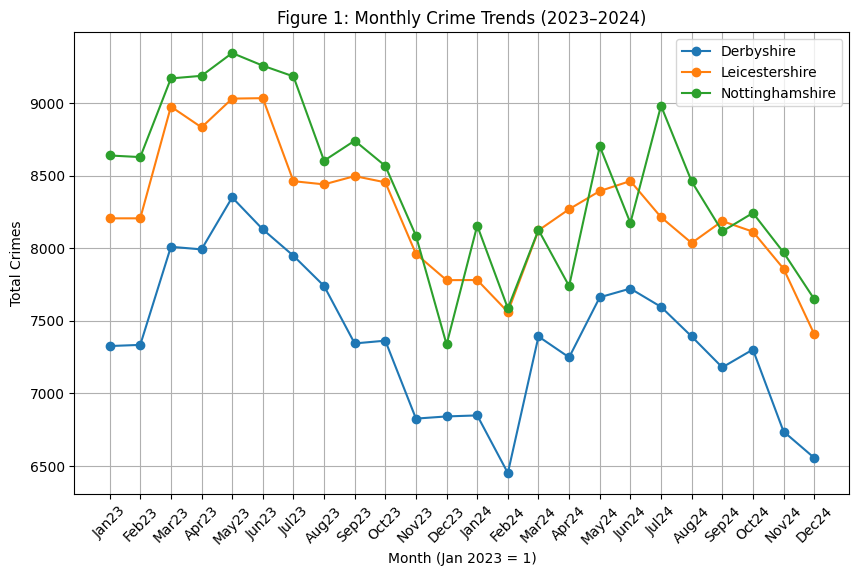

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert to Pandas
monthly_trends = monthly_crime_trends.toPandas()

# Ensure Year and MonthNum are numeric
monthly_trends['Year'] = monthly_trends['Year'].astype(int)
monthly_trends['MonthNum'] = monthly_trends['MonthNum'].astype(int)

# Create a sequential month index: Jan 2023 = 1, Feb 2023 = 2, ..., Dec 2024 = 24
monthly_trends['MonthSeq'] = (monthly_trends['Year'] - 2023) * 12 + monthly_trends['MonthNum']

# Aggregate total crimes per county and sequential month
agg_trends = monthly_trends.groupby(['County', 'MonthSeq'])['Total_Crimes'].sum().reset_index()

# Line Plot
plt.figure(figsize=(10,6))
for county in agg_trends['County'].unique():
    subset = agg_trends[agg_trends['County'] == county]
    plt.plot(subset['MonthSeq'], subset['Total_Crimes'], marker='o', label=county)

plt.title("Figure 1: Monthly Crime Trends (2023–2024)")
plt.xlabel("Month (Jan 2023 = 1)")
plt.ylabel("Total Crimes")
plt.xticks(range(1,25), 
           ['Jan23','Feb23','Mar23','Apr23','May23','Jun23','Jul23','Aug23','Sep23','Oct23','Nov23','Dec23',
            'Jan24','Feb24','Mar24','Apr24','May24','Jun24','Jul24','Aug24','Sep24','Oct24','Nov24','Dec24'], 
           rotation=45)
plt.legend()
plt.grid(True)
plt.show()


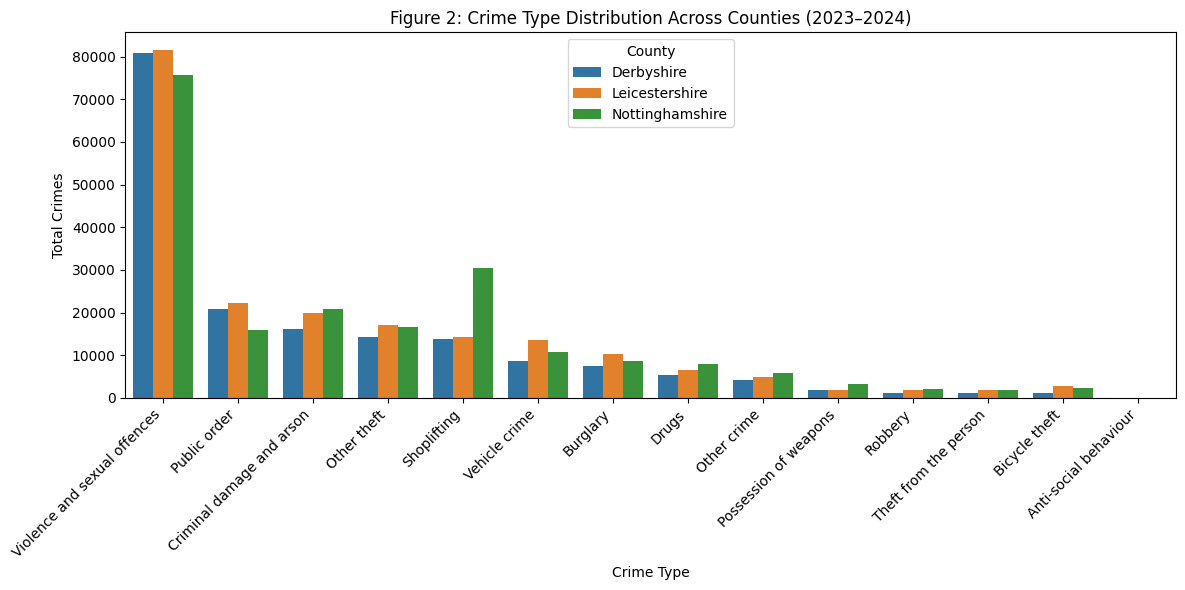

In [4]:
crime_analysis = crime_type_analysis.toPandas()

plt.figure(figsize=(12,6))
import seaborn as sns
sns.barplot(data=crime_analysis, x='Crime_Type', y='Frequency', hue='County')
plt.title("Figure 2: Crime Type Distribution Across Counties (2023–2024)")
plt.xlabel("Crime Type")
plt.ylabel("Total Crimes")
plt.xticks(rotation=45, ha="right")
plt.legend(title="County")
plt.tight_layout()
plt.show()


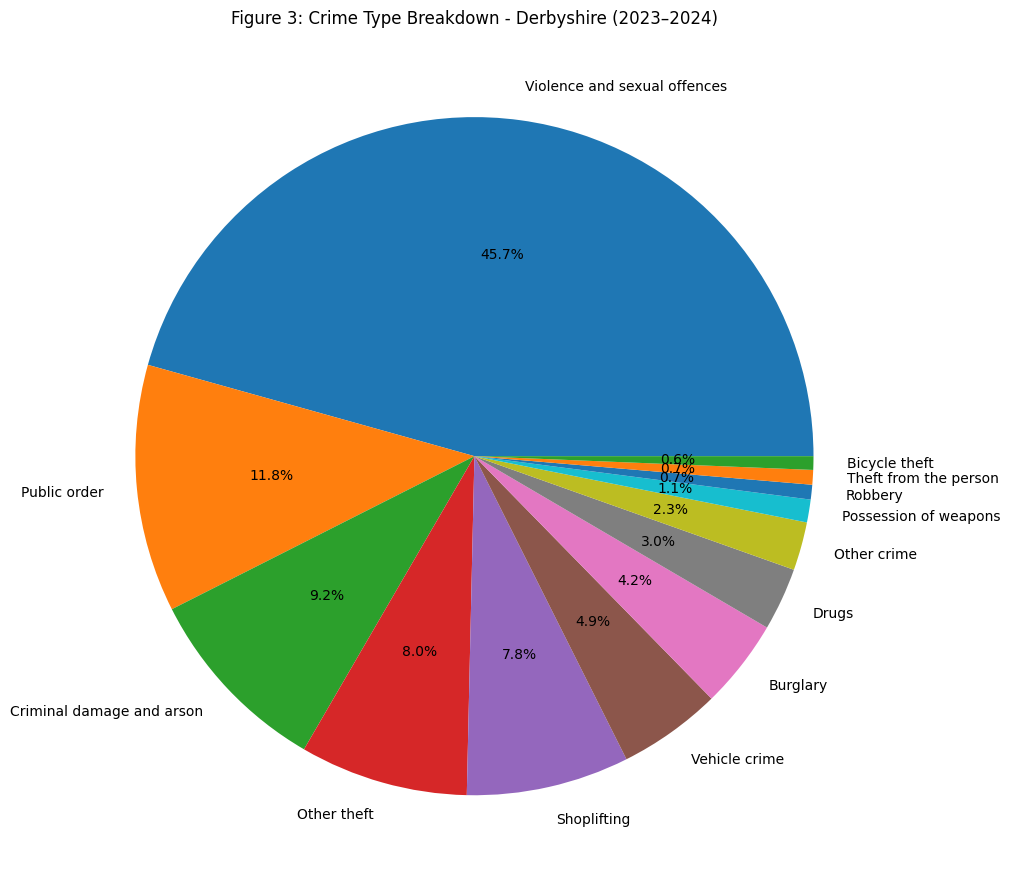

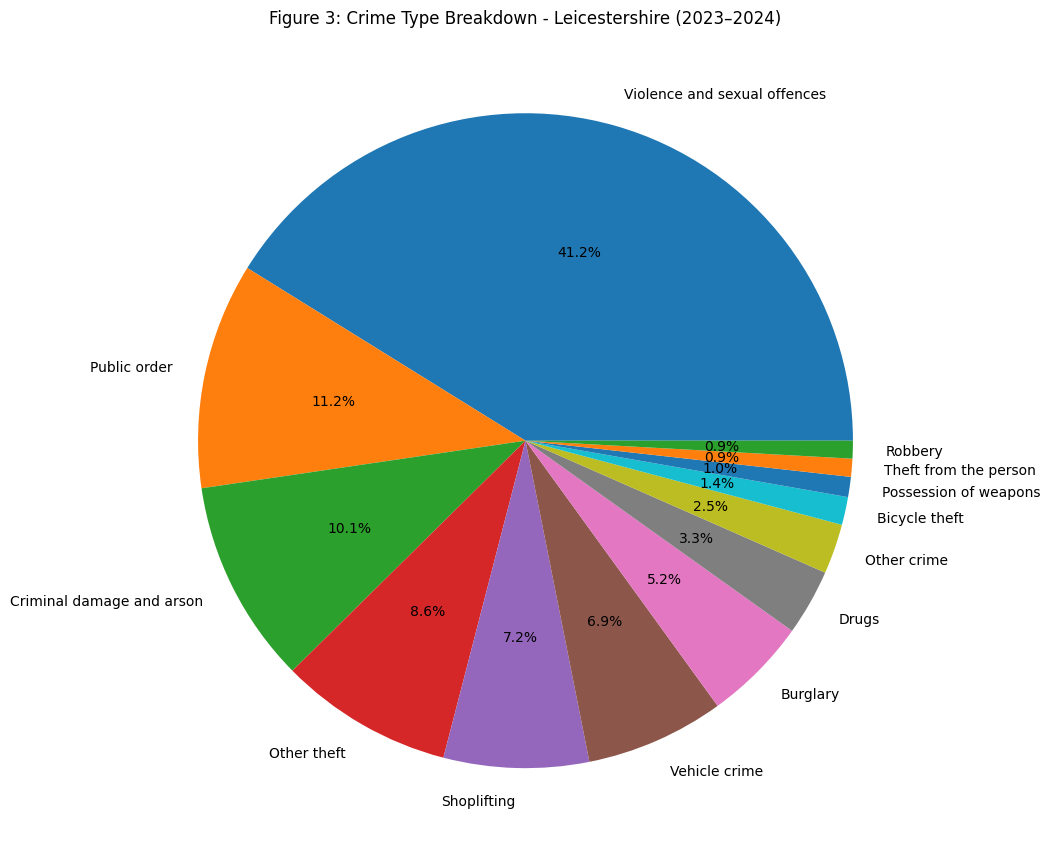

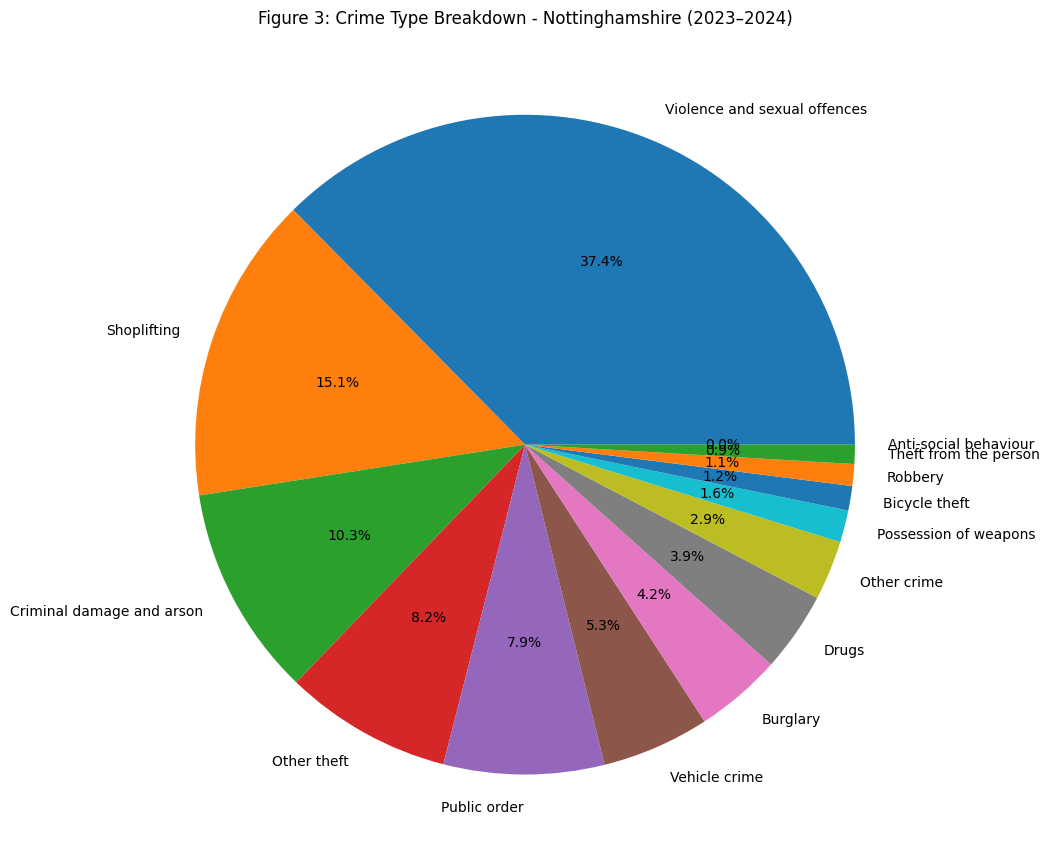

In [5]:
counties = crime_analysis['County'].unique()

for county in counties:
    subset = crime_analysis[crime_analysis['County'] == county]
    plt.figure(figsize=(10,9))
    plt.pie(subset['Frequency'], labels=subset['Crime_Type'], autopct='%1.1f%%')
    plt.title(f"Figure 3: Crime Type Breakdown - {county} (2023–2024)")
    plt.tight_layout()
    plt.show()


In [6]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# Load your dataset
data_path = "/kaggle/input/loan-predict/Part B - Loan Prediction Dataset/Part B - Loan Prediction Dataset"
df = spark.read.option("header", True).option("inferSchema", True).csv(data_path)
df.show(5)

# Handle missing values 
df = df.na.drop()

# Define categorical and numeric columns
categorical_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]

# Index + One-Hot Encode categorical columns
indexers = [StringIndexer(inputCol=col, outputCol=col + "_Index") for col in categorical_cols]
encoders = [OneHotEncoder(inputCol=col + "_Index", outputCol=col + "_Vec") for col in categorical_cols]

# Assemble all features
assembler_inputs = [col + "_Vec" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Label indexer (target column)
label_indexer = StringIndexer(inputCol="Loan_Status", outputCol="label")

# Create pipeline
pipeline = Pipeline(stages=indexers + encoders + [assembler, label_indexer])

# Fit and transform the data
model = pipeline.fit(df)
df_prepared = model.transform(df)

# Split data
train_data, test_data = df_prepared.randomSplit([0.72, 0.28], seed=42)

# Show the processed columns
df_prepared.select("features", "label").show(5, truncate=False)


+--------+------+-------+----------+------------+-------------+---------------+-----------------+----------+----------------+--------------+-------------+-----------+
| Loan_ID|Gender|Married|Dependents|   Education|Self_Employed|ApplicantIncome|CoapplicantIncome|LoanAmount|Loan_Amount_Term|Credit_History|Property_Area|Loan_Status|
+--------+------+-------+----------+------------+-------------+---------------+-----------------+----------+----------------+--------------+-------------+-----------+
|LP001002|  Male|     No|         0|    Graduate|           No|           5849|              0.0|      NULL|             360|             1|        Urban|          Y|
|LP001003|  Male|    Yes|         1|    Graduate|           No|           4583|           1508.0|       128|             360|             1|        Rural|          N|
|LP001005|  Male|    Yes|         0|    Graduate|          Yes|           3000|              0.0|        66|             360|             1|        Urban|          Y

25/11/14 11:15:26 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


                 Model  Accuracy  Precision    Recall
0  Logistic Regression  0.767857   0.762521  0.767857
1        Decision Tree  0.750000   0.738681  0.750000
2          Naive Bayes  0.553571   0.613088  0.553571


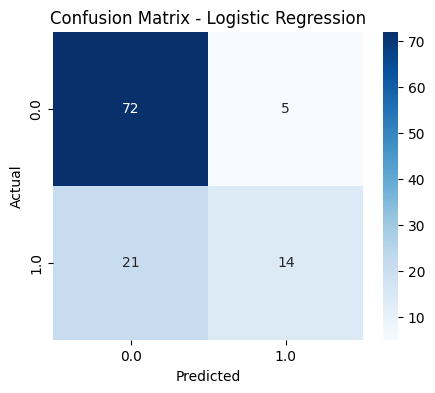

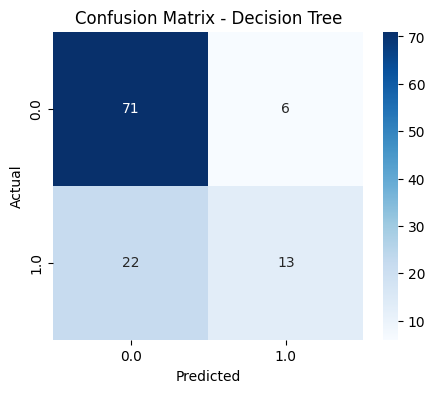

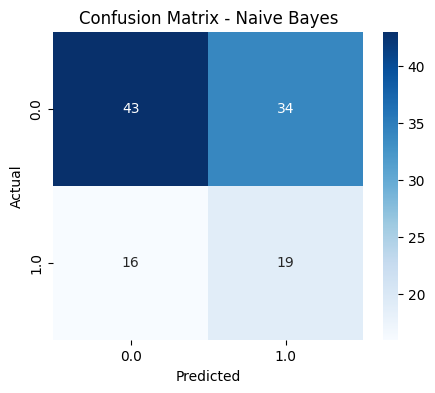

In [7]:
# Task 2: Apply Classification Algorithms Using MLlib

from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import seaborn as sns
import matplotlib.pyplot as plt

#  Define evaluation function
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall")

def evaluate_model(model, test_data):
    """Train model and return metrics + predictions"""
    predictions = model.transform(test_data)
    acc = evaluator_acc.evaluate(predictions)
    prec = evaluator_prec.evaluate(predictions)
    rec = evaluator_rec.evaluate(predictions)
    return acc, prec, rec, predictions

#  Train Models
# Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_data)

# Decision Tree
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", seed=42)
dt_model = dt.fit(train_data)

# Naive Bayes
nb = NaiveBayes(featuresCol="features", labelCol="label")
nb_model = nb.fit(train_data)


#  Evaluate Models
lr_acc, lr_prec, lr_rec, lr_predictions = evaluate_model(lr_model, test_data)
dt_acc, dt_prec, dt_rec, dt_predictions = evaluate_model(dt_model, test_data)
nb_acc, nb_prec, nb_rec, nb_predictions = evaluate_model(nb_model, test_data)


#  Print Metrics in Table
import pandas as pd

metrics_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Naive Bayes"],
    "Accuracy": [lr_acc, dt_acc, nb_acc],
    "Precision": [lr_prec, dt_prec, nb_prec],
    "Recall": [lr_rec, dt_rec, nb_rec]
})
print(metrics_table)


#  Confusion Matrix Function
def confusion_matrix(predictions, model_name):
    """Create a heatmap for confusion matrix"""
    cm = predictions.groupBy("label", "prediction").count().toPandas()
    # Pivot table for heatmap
    cm_pivot = cm.pivot(index="label", columns="prediction", values="count").fillna(0)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm_pivot, annot=True, fmt="g", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


#  Plot Confusion Matrices
confusion_matrix(lr_predictions, "Logistic Regression")
confusion_matrix(dt_predictions, "Decision Tree")
confusion_matrix(nb_predictions, "Naive Bayes")
